<a href="https://colab.research.google.com/github/Dapaaj/Dis_predic/blob/main/pythonmlmodels.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
!pip install -q ucimlrepo tensorflow xgboost

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    roc_auc_score
)
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

import xgboost as xgb
from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [7]:
# Fetch UCI Heart Disease dataset (id=45)
heart = fetch_ucirepo(id=45)  # Cleveland etc.

X_raw = heart.data.features
y_raw = heart.data.targets

df = pd.concat([X_raw, y_raw], axis=1)
print("Raw dataset shape:", df.shape)
df.head()

Raw dataset shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [8]:
# Binary target: 0 = no disease, 1 = disease (1–4)
df['num'] = df['num'].apply(lambda x: 1 if x > 0 else 0)
print("Target value counts:\n", df['num'].value_counts())

# Replace '?' with NaN and convert all to numeric
df = df.replace('?', np.nan)
df = df.apply(pd.to_numeric, errors='coerce')

print("\nMissing values after numeric conversion:\n", df.isnull().sum())

# Impute 'ca' and 'thal' with mode (most frequent value)
df['ca'] = df['ca'].fillna(df['ca'].mode()[0])
df['thal'] = df['thal'].fillna(df['thal'].mode()[0])

print("\nMissing values after imputation:\n", df.isnull().sum())

Target value counts:
 num
0    164
1    139
Name: count, dtype: int64

Missing values after numeric conversion:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64

Missing values after imputation:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64


In [9]:
# Split features and target
X = df.drop('num', axis=1)
y = df['num']

# Categorical and numeric columns from Cleveland description
categorical_cols = [
    "sex", "cp", "fbs",
    "restecg", "exang",
    "slope", "ca", "thal"
]

numeric_cols = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

# One-hot encode categorical features
X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)
print("Shape after encoding:", X.shape)

# Scale numeric features
scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

print("Final feature matrix shape:", X.shape)
print("Total missing after preprocessing:", X.isnull().sum().sum())

# Save cleaned dataset (optional)
clean_df = pd.concat([X, y], axis=1)
clean_df.to_csv("heart_cleaned.csv", index=False)

Shape after encoding: (303, 20)
Final feature matrix shape: (303, 20)
Total missing after preprocessing: 0


In [10]:
# ============================================================
# Train–test split + feature selection with Random Forest
# ============================================================

# 1) Train–test split on all features
X_train_full, X_test_full, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set (full features):", X_train_full.shape)
print("Test set (full features):", X_test_full.shape)

# 2) Feature selection using Random Forest importance
fs_rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
fs_rf.fit(X_train_full, y_train)

importances = fs_rf.feature_importances_
feature_names = X.columns

feat_imp_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print("\nTop 15 features by RF importance:")
print(feat_imp_df.head(15))

# Keep top k features (you can change k)
k = 10
top_features = feat_imp_df["feature"].iloc[:k].tolist()
print(f"\nUsing top {k} features:")
print(top_features)

# Reduced feature sets for all models
X_train = X_train_full[top_features].copy()
X_test = X_test_full[top_features].copy()

print("\nTraining set (selected features):", X_train.shape)
print("Test set (selected features):", X_test.shape)

# Save selected-feature dataset (optional)
selected_df = pd.concat([X[top_features], y], axis=1)
selected_df.to_csv("heart_selected_features.csv", index=False)

Training set (full features): (242, 20)
Test set (full features): (61, 20)

Top 15 features by RF importance:
      feature  importance
3     thalach    0.135746
19   thal_7.0    0.113223
4     oldpeak    0.103921
0         age    0.096305
8        cp_4    0.096171
2        chol    0.087608
1    trestbps    0.080917
12    exang_1    0.050464
5       sex_1    0.043650
13    slope_2    0.038568
15     ca_1.0    0.037001
11  restecg_2    0.023529
7        cp_3    0.020903
16     ca_2.0    0.019037
6        cp_2    0.014706

Using top 10 features:
['thalach', 'thal_7.0', 'oldpeak', 'age', 'cp_4', 'chol', 'trestbps', 'exang_1', 'sex_1', 'slope_2']

Training set (selected features): (242, 10)
Test set (selected features): (61, 10)


In [11]:
def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(4, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["No disease", "Disease"],
        yticklabels=["No disease", "Disease"]
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [12]:
def plot_roc_curve_generic(y_true, y_score, title):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(4, 4))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

In [13]:
def plot_training_history(history, title):
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]

    plt.figure(figsize=(5, 4))
    plt.plot(acc, label="Training accuracy")
    plt.plot(val_acc, label="Validation accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

Logistic Regression test accuracy: 0.8852459016393442

Logistic Regression classification report:
               precision    recall  f1-score   support

           0       0.91      0.88      0.89        33
           1       0.86      0.89      0.88        28

    accuracy                           0.89        61
   macro avg       0.88      0.89      0.88        61
weighted avg       0.89      0.89      0.89        61

Logistic Regression confusion matrix:
 [[29  4]
 [ 3 25]]


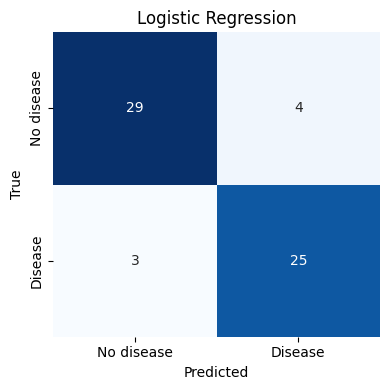

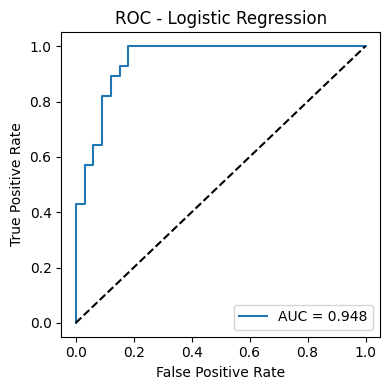

In [14]:
# ==========================
# Logistic Regression
# ==========================
log_reg = LogisticRegression(
    solver="lbfgs",
    max_iter=1000,
    random_state=42
)
log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)
y_score_lr = log_reg.predict_proba(X_test)[:, 1]

acc_lr = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression test accuracy:", acc_lr)
print("\nLogistic Regression classification report:\n",
      classification_report(y_test, y_pred_lr))

cm_lr = confusion_matrix(y_test, y_pred_lr)
print("Logistic Regression confusion matrix:\n", cm_lr)
plot_confusion_matrix(cm_lr, "Logistic Regression")

plot_roc_curve_generic(y_test, y_score_lr, "ROC - Logistic Regression")

SVM test accuracy: 0.9180327868852459

SVM classification report:
               precision    recall  f1-score   support

           0       0.97      0.88      0.92        33
           1       0.87      0.96      0.92        28

    accuracy                           0.92        61
   macro avg       0.92      0.92      0.92        61
weighted avg       0.92      0.92      0.92        61

SVM confusion matrix:
 [[29  4]
 [ 1 27]]


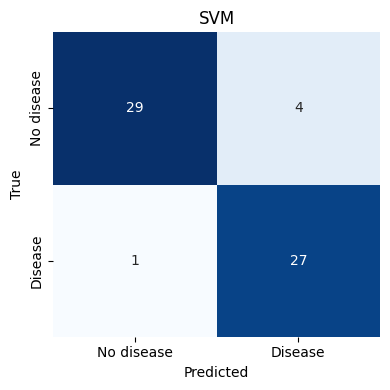

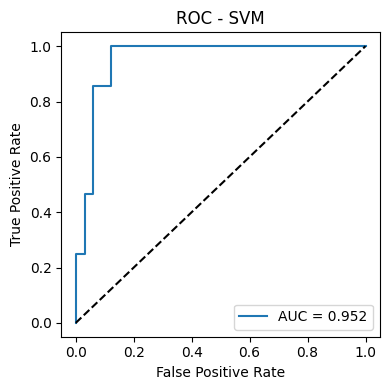

In [15]:
# ==========================
# Support Vector Machine (SVM)
# ==========================
svm_clf = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)
svm_clf.fit(X_train, y_train)

y_pred_svm = svm_clf.predict(X_test)
y_score_svm = svm_clf.predict_proba(X_test)[:, 1]

acc_svm = accuracy_score(y_test, y_pred_svm)
print("SVM test accuracy:", acc_svm)
print("\nSVM classification report:\n",
      classification_report(y_test, y_pred_svm))

cm_svm = confusion_matrix(y_test, y_pred_svm)
print("SVM confusion matrix:\n", cm_svm)
plot_confusion_matrix(cm_svm, "SVM")

plot_roc_curve_generic(y_test, y_score_svm, "ROC - SVM")

Naive Bayes test accuracy: 0.9180327868852459

Naive Bayes classification report:
               precision    recall  f1-score   support

           0       1.00      0.85      0.92        33
           1       0.85      1.00      0.92        28

    accuracy                           0.92        61
   macro avg       0.92      0.92      0.92        61
weighted avg       0.93      0.92      0.92        61

Naive Bayes confusion matrix:
 [[28  5]
 [ 0 28]]


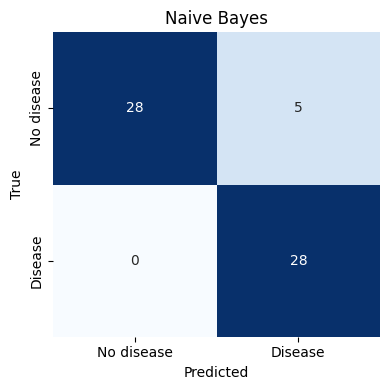

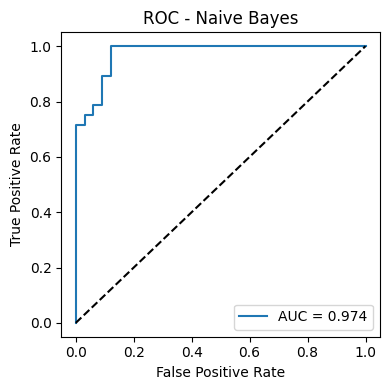

In [16]:
# ==========================
# Gaussian Naive Bayes
# ==========================
nb_clf = GaussianNB()
nb_clf.fit(X_train, y_train)

y_pred_nb = nb_clf.predict(X_test)
y_score_nb = nb_clf.predict_proba(X_test)[:, 1]

acc_nb = accuracy_score(y_test, y_pred_nb)
print("Naive Bayes test accuracy:", acc_nb)
print("\nNaive Bayes classification report:\n",
      classification_report(y_test, y_pred_nb))

cm_nb = confusion_matrix(y_test, y_pred_nb)
print("Naive Bayes confusion matrix:\n", cm_nb)
plot_confusion_matrix(cm_nb, "Naive Bayes")

plot_roc_curve_generic(y_test, y_score_nb, "ROC - Naive Bayes")

AdaBoost test accuracy: 0.9016393442622951

AdaBoost classification report:
               precision    recall  f1-score   support

           0       0.91      0.91      0.91        33
           1       0.89      0.89      0.89        28

    accuracy                           0.90        61
   macro avg       0.90      0.90      0.90        61
weighted avg       0.90      0.90      0.90        61

AdaBoost confusion matrix:
 [[30  3]
 [ 3 25]]


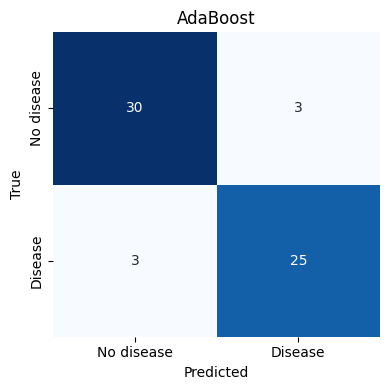

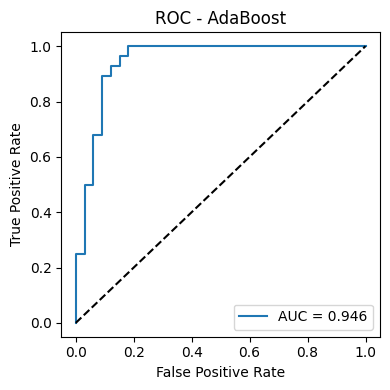

In [17]:
# ==========================
# AdaBoost
# ==========================
ada_clf = AdaBoostClassifier(
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)
ada_clf.fit(X_train, y_train)

y_pred_ada = ada_clf.predict(X_test)
y_score_ada = ada_clf.predict_proba(X_test)[:, 1]

acc_ada = accuracy_score(y_test, y_pred_ada)
print("AdaBoost test accuracy:", acc_ada)
print("\nAdaBoost classification report:\n",
      classification_report(y_test, y_pred_ada))

cm_ada = confusion_matrix(y_test, y_pred_ada)
print("AdaBoost confusion matrix:\n", cm_ada)
plot_confusion_matrix(cm_ada, "AdaBoost")

plot_roc_curve_generic(y_test, y_score_ada, "ROC - AdaBoost")

In [18]:
# ==========================
# Simple LVQ1 implementation
# ==========================
class LVQ1:
    def __init__(self, n_prototypes_per_class=2, learning_rate=0.01, n_epochs=50, random_state=42):
        self.n_prototypes_per_class = n_prototypes_per_class
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.random_state = random_state
        self.prototypes_ = None
        self.prototype_labels_ = None

    def fit(self, X, y):
        rng = np.random.RandomState(self.random_state)
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=int)

        classes = np.unique(y)
        prototypes = []
        proto_labels = []

        # initialize prototypes by sampling from data of each class
        for c in classes:
            X_c = X[y == c]
            if X_c.shape[0] < self.n_prototypes_per_class:
                idx = rng.choice(X_c.shape[0], self.n_prototypes_per_class, replace=True)
            else:
                idx = rng.choice(X_c.shape[0], self.n_prototypes_per_class, replace=False)
            prototypes.append(X_c[idx])
            proto_labels.extend([c] * self.n_prototypes_per_class)

        self.prototypes_ = np.vstack(prototypes)
        self.prototype_labels_ = np.array(proto_labels)

        # training
        for epoch in range(self.n_epochs):
            indices = rng.permutation(X.shape[0])
            for i in indices:
                xi = X[i]
                yi = y[i]

                # nearest prototype
                dists = np.linalg.norm(self.prototypes_ - xi, axis=1)
                j = np.argmin(dists)

                if self.prototype_labels_[j] == yi:
                    # move prototype towards sample
                    self.prototypes_[j] += self.learning_rate * (xi - self.prototypes_[j])
                else:
                    # move prototype away from sample
                    self.prototypes_[j] -= self.learning_rate * (xi - self.prototypes_[j])

        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        dists = np.linalg.norm(self.prototypes_[None, :, :] - X[:, None, :], axis=2)
        nearest = np.argmin(dists, axis=1)
        return self.prototype_labels_[nearest]

LVQ test accuracy: 0.8852459016393442

LVQ classification report:
               precision    recall  f1-score   support

           0       0.86      0.94      0.90        33
           1       0.92      0.82      0.87        28

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.88        61

LVQ confusion matrix:
 [[31  2]
 [ 5 23]]


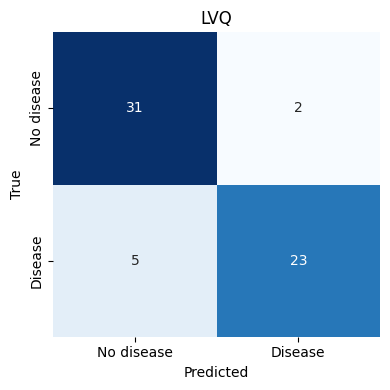

In [19]:
# ==========================
# LVQ on selected features
# ==========================
lvq = LVQ1(
    n_prototypes_per_class=3,
    learning_rate=0.01,
    n_epochs=100,
    random_state=42
)
lvq.fit(X_train, y_train)

y_pred_lvq = lvq.predict(X_test)

acc_lvq = accuracy_score(y_test, y_pred_lvq)
print("LVQ test accuracy:", acc_lvq)
print("\nLVQ classification report:\n",
      classification_report(y_test, y_pred_lvq))

cm_lvq = confusion_matrix(y_test, y_pred_lvq)
print("LVQ confusion matrix:\n", cm_lvq)
plot_confusion_matrix(cm_lvq, "LVQ")

Best Random Forest Parameters:
{'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300}

Random Forest test accuracy: 0.8852459016393442

Random Forest classification report:
               precision    recall  f1-score   support

           0       0.91      0.88      0.89        33
           1       0.86      0.89      0.88        28

    accuracy                           0.89        61
   macro avg       0.88      0.89      0.88        61
weighted avg       0.89      0.89      0.89        61

Random Forest confusion matrix:
 [[29  4]
 [ 3 25]]


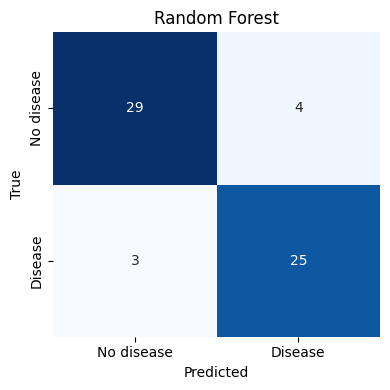

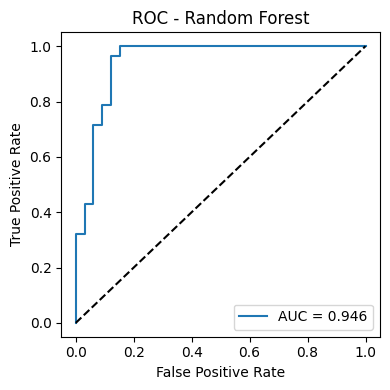

In [20]:
# ==========================
# Random Forest with GridSearchCV (on selected features)
# ==========================
rf = RandomForestClassifier(random_state=42)

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Random Forest Parameters:")
print(grid_search.best_params_)

best_rf = grid_search.best_estimator_

y_pred_rf = best_rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
print("\nRandom Forest test accuracy:", acc_rf)
print("\nRandom Forest classification report:\n",
      classification_report(y_test, y_pred_rf))

cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Random Forest confusion matrix:\n", cm_rf)
plot_confusion_matrix(cm_rf, "Random Forest")

# ROC for RF (use probability of class 1)
y_score_rf = best_rf.predict_proba(X_test)[:, 1]
plot_roc_curve_generic(y_test, y_score_rf, "ROC - Random Forest")

XGBoost test accuracy: 0.8524590163934426

XGBoost classification report:
               precision    recall  f1-score   support

           0       0.90      0.82      0.86        33
           1       0.81      0.89      0.85        28

    accuracy                           0.85        61
   macro avg       0.85      0.86      0.85        61
weighted avg       0.86      0.85      0.85        61

XGBoost confusion matrix:
 [[27  6]
 [ 3 25]]


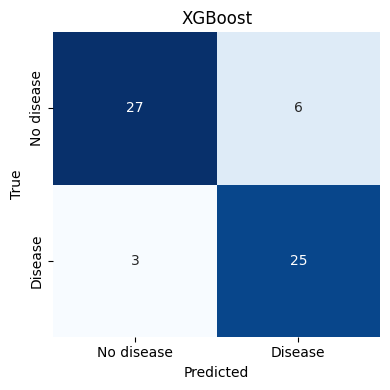

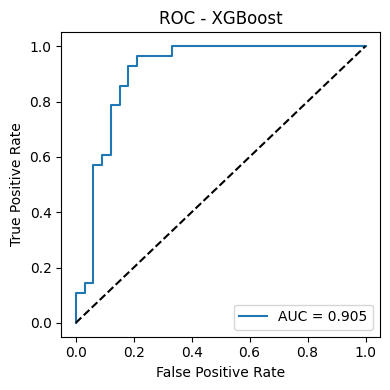

In [21]:
# ==========================
# XGBoost (on selected features)
# ==========================
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train, y_train)
xgb_acc = xgb_model.score(X_test, y_test)
print("XGBoost test accuracy:", xgb_acc)

y_pred_xgb = xgb_model.predict(X_test)
print("\nXGBoost classification report:\n",
      classification_report(y_test, y_pred_xgb))

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print("XGBoost confusion matrix:\n", cm_xgb)
plot_confusion_matrix(cm_xgb, "XGBoost")

# ROC for XGBoost
y_score_xgb = xgb_model.predict_proba(X_test)[:, 1]
plot_roc_curve_generic(y_test, y_score_xgb, "ROC - XGBoost")

In [22]:
# ==========================
# Prepare data for ANN/CNN
# ==========================
X_train_np = np.asarray(X_train, dtype="float32")
X_test_np  = np.asarray(X_test, dtype="float32")
y_train_np = np.asarray(y_train, dtype="float32")
y_test_np  = np.asarray(y_test, dtype="float32")

input_dim = X_train_np.shape[1]
print("Input dim:", input_dim)

Input dim: 10


In [23]:
# ==========================
# ANN (on selected features)
# ==========================
ann_model = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

ann_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_ann = ann_model.fit(
    X_train_np, y_train_np,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=0
)

ann_loss, ann_acc = ann_model.evaluate(X_test_np, y_test_np, verbose=0)
print("ANN test accuracy:", ann_acc)

ANN test accuracy: 0.8524590134620667


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step

ANN classification report:
               precision    recall  f1-score   support

         0.0       0.83      0.91      0.87        33
         1.0       0.88      0.79      0.83        28

    accuracy                           0.85        61
   macro avg       0.86      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61

ANN confusion matrix:
 [[30  3]
 [ 6 22]]


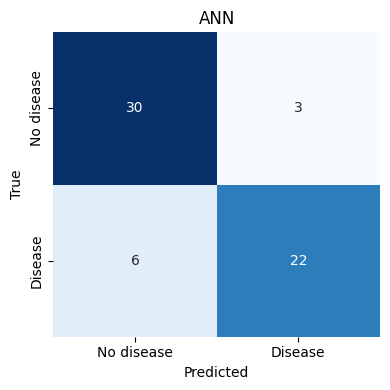

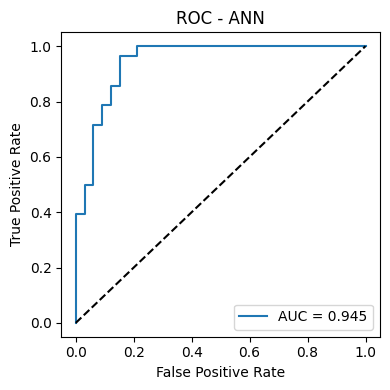

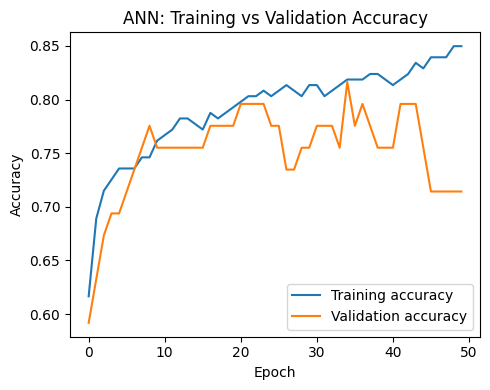

In [24]:
# Confusion matrix and ROC for ANN
y_score_ann = ann_model.predict(X_test_np).ravel()
y_pred_ann = (y_score_ann >= 0.5).astype(int)

cm_ann = confusion_matrix(y_test_np, y_pred_ann)
print("\nANN classification report:\n",
      classification_report(y_test_np, y_pred_ann))
print("ANN confusion matrix:\n", cm_ann)
plot_confusion_matrix(cm_ann, "ANN")

plot_roc_curve_generic(y_test_np, y_score_ann, "ROC - ANN")

# Training vs validation accuracy
plot_training_history(history_ann, "ANN: Training vs Validation Accuracy")

In [25]:
# ==========================
# 1D CNN (on selected features)
# ==========================
# Reshape for 1D CNN: (samples, timesteps, channels)
X_train_cnn = X_train_np.reshape(-1, input_dim, 1)
X_test_cnn  = X_test_np.reshape(-1, input_dim, 1)

cnn_model = keras.Sequential([
    layers.Conv1D(32, 3, activation="relu", input_shape=(input_dim, 1)),
    layers.MaxPooling1D(2),
    layers.Conv1D(64, 3, activation="relu"),
    layers.GlobalAveragePooling1D(),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

cnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_cnn = cnn_model.fit(
    X_train_cnn, y_train_np,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=0
)

cnn_loss, cnn_acc = cnn_model.evaluate(X_test_cnn, y_test_np, verbose=0)
print("CNN test accuracy:", cnn_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


CNN test accuracy: 0.8032786846160889


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step

CNN classification report:
               precision    recall  f1-score   support

         0.0       0.77      0.91      0.83        33
         1.0       0.86      0.68      0.76        28

    accuracy                           0.80        61
   macro avg       0.82      0.79      0.80        61
weighted avg       0.81      0.80      0.80        61

CNN confusion matrix:
 [[30  3]
 [ 9 19]]


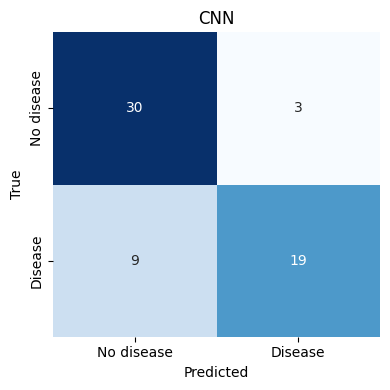

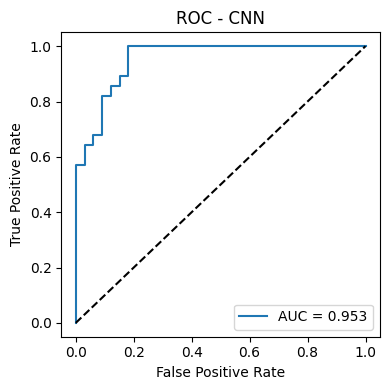

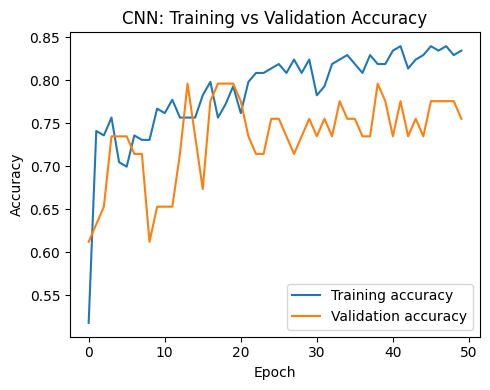

In [26]:
# Confusion matrix and ROC for CNN
y_score_cnn = cnn_model.predict(X_test_cnn).ravel()
y_pred_cnn = (y_score_cnn >= 0.5).astype(int)

cm_cnn = confusion_matrix(y_test_np, y_pred_cnn)
print("\nCNN classification report:\n",
      classification_report(y_test_np, y_pred_cnn))
print("CNN confusion matrix:\n", cm_cnn)
plot_confusion_matrix(cm_cnn, "CNN")

plot_roc_curve_generic(y_test_np, y_score_cnn, "ROC - CNN")

# Training vs validation accuracy
plot_training_history(history_cnn, "CNN: Training vs Validation Accuracy")

In [27]:
# ==========================
# Final summary: Accuracy and AUC for all models
# ==========================
summary_rows = []

def add_model_summary(name, y_true, y_pred, y_score=None):
    acc = accuracy_score(y_true, y_pred)
    if y_score is not None:
        auc_val = roc_auc_score(y_true, y_score)
    else:
        auc_val = None
    summary_rows.append({
        "Model": name,
        "Accuracy": acc,
        "AUC": auc_val
    })

add_model_summary("Random Forest", y_test, y_pred_rf, y_score_rf)
add_model_summary("XGBoost", y_test, y_pred_xgb, y_score_xgb)
add_model_summary("ANN", y_test_np, y_pred_ann, y_score_ann)
add_model_summary("CNN", y_test_np, y_pred_cnn, y_score_cnn)
add_model_summary("Logistic Regression", y_test, y_pred_lr, y_score_lr)
add_model_summary("SVM", y_test, y_pred_svm, y_score_svm)
add_model_summary("Naive Bayes", y_test, y_pred_nb, y_score_nb)
add_model_summary("AdaBoost", y_test, y_pred_ada, y_score_ada)
add_model_summary("LVQ", y_test, y_pred_lvq, None)  # no scores => no AUC

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values("Accuracy", ascending=False)

print(summary_df)

# Optional: save for your dissertation/report
summary_df.to_csv("model_performance_summary.csv", index=False)

                 Model  Accuracy       AUC
6          Naive Bayes  0.918033  0.974026
5                  SVM  0.918033  0.952381
7             AdaBoost  0.901639  0.945887
0        Random Forest  0.885246  0.945887
4  Logistic Regression  0.885246  0.948052
8                  LVQ  0.885246       NaN
1              XGBoost  0.852459  0.904762
2                  ANN  0.852459  0.944805
3                  CNN  0.803279  0.953463
